In [2]:
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional

In [3]:
# Load the CSV file into a DataFrame
df = pd.read_csv("C:/Users/T sreenivasulu/Downloads/archive (37)/delhi_aqi.csv")

In [4]:
# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

In [5]:
# Set 'date' column as index
df.set_index('date', inplace=True)

In [6]:
print(df)

                          co     no     no2     o3     so2   pm2_5    pm10  \
date                                                                         
2020-11-25 01:00:00  2616.88   2.18   70.60  13.59   38.62  364.61  411.73   
2020-11-25 02:00:00  3631.59  23.25   89.11   0.33   54.36  420.96  486.21   
2020-11-25 03:00:00  4539.49  52.75  100.08   1.11   68.67  463.68  541.95   
2020-11-25 04:00:00  4539.49  50.96  111.04   6.44   78.20  454.81  534.00   
2020-11-25 05:00:00  4379.27  42.92  117.90  17.17   87.74  448.14  529.19   
...                      ...    ...     ...    ...     ...     ...     ...   
2023-01-24 04:00:00  1762.39   4.64   37.01  33.26   30.52  231.15  289.84   
2023-01-24 05:00:00  1735.69   6.82   34.96  46.49   34.33  225.08  280.52   
2023-01-24 06:00:00  1922.61   8.16   40.10  56.51   43.39  242.49  296.07   
2023-01-24 07:00:00  1361.85   9.05   52.78  71.53  100.14  165.67  191.82   
2023-01-24 08:00:00  1134.87   8.61   56.89  80.11  110.63  123.

In [7]:
# Resample the data to daily frequency and aggregate using mean (or sum, median, etc. depending on your requirement)
df1 = df.resample('D').mean()

# Now 'daily_data' contains daily average values of your variables
print(df1.head())

                     co         no        no2         o3        so2  \
date                                                                  
2020-11-25  2971.566087  14.880000  93.549130  26.791304  82.430870   
2020-11-26  2314.806667  24.443750  65.418750  20.753333  65.158333   
2020-11-27  1592.159583   4.934167  56.221667  43.925000  41.485000   
2020-11-28  2461.115833  11.879583  70.046667  50.372500  41.515417   
2020-11-29  4516.680417  65.719583  93.949583  34.696250  77.785417   

                 pm2_5        pm10        nh3  
date                                           
2020-11-25  342.301739  405.037826  26.720435  
2020-11-26  180.754167  226.001250  21.993750  
2020-11-27  115.901667  143.952500  20.280000  
2020-11-28  197.889167  234.861250  23.145000  
2020-11-29  329.381667  404.049583  47.233750  


In [8]:
# Print missing values
missing_values = df1.isnull().sum()
print("Missing values in daily_data:")
print(missing_values)

Missing values in daily_data:
co       2
no       2
no2      2
o3       2
so2      2
pm2_5    2
pm10     2
nh3      2
dtype: int64


In [9]:
# Fill missing values with the mean of respective column
daily_data = df1.fillna(df1.mean())

In [10]:
# Print missing values
missing_values = daily_data.isnull().sum()
print("Missing values in daily_data:")
print(missing_values)

Missing values in daily_data:
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64


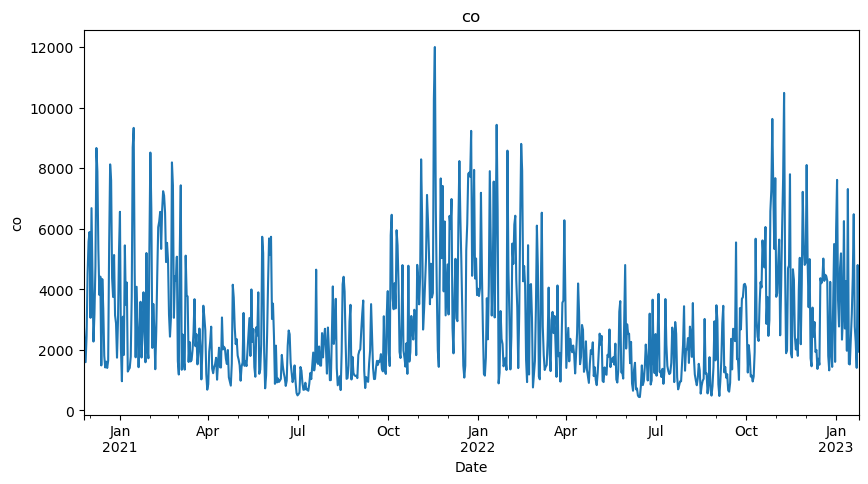

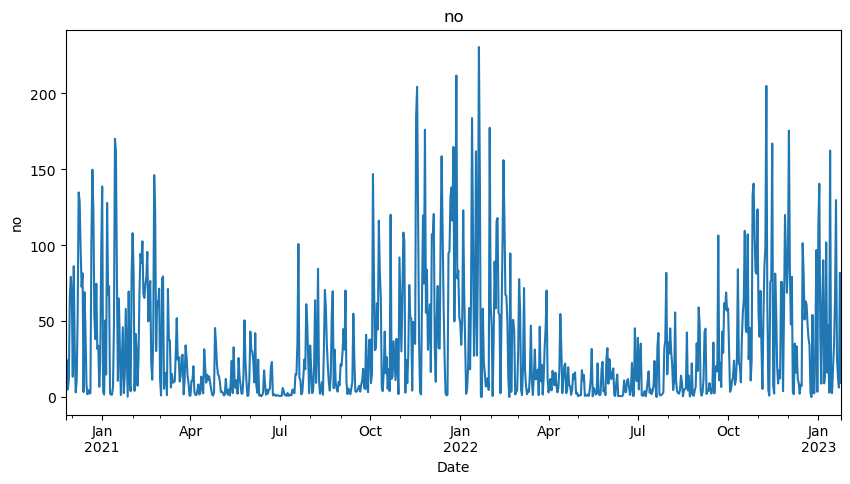

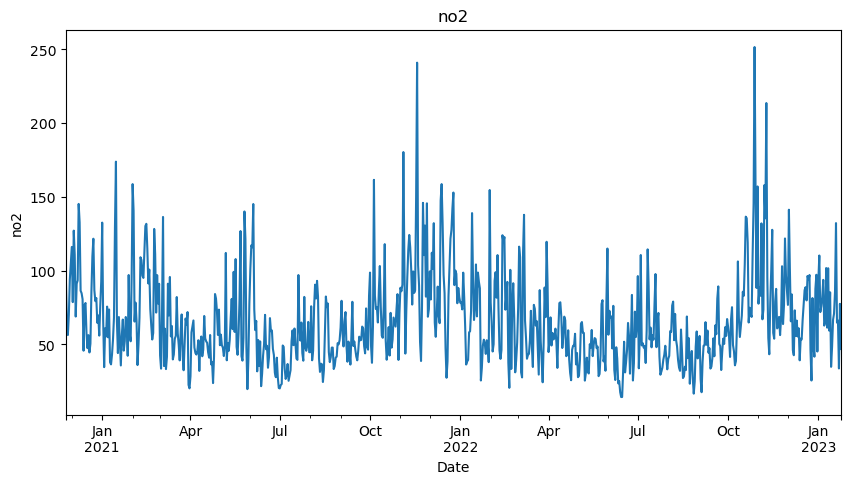

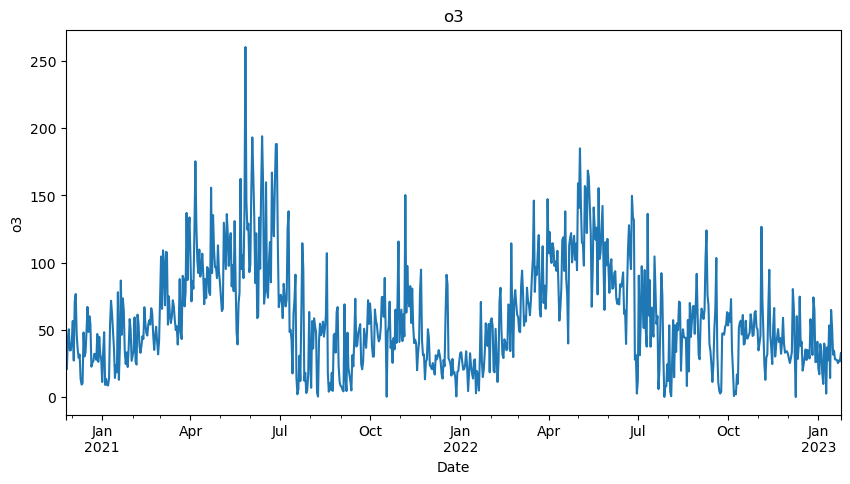

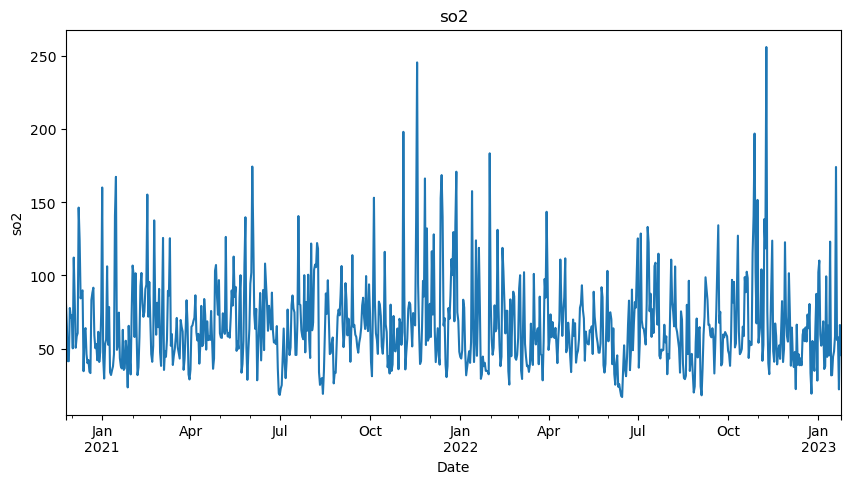

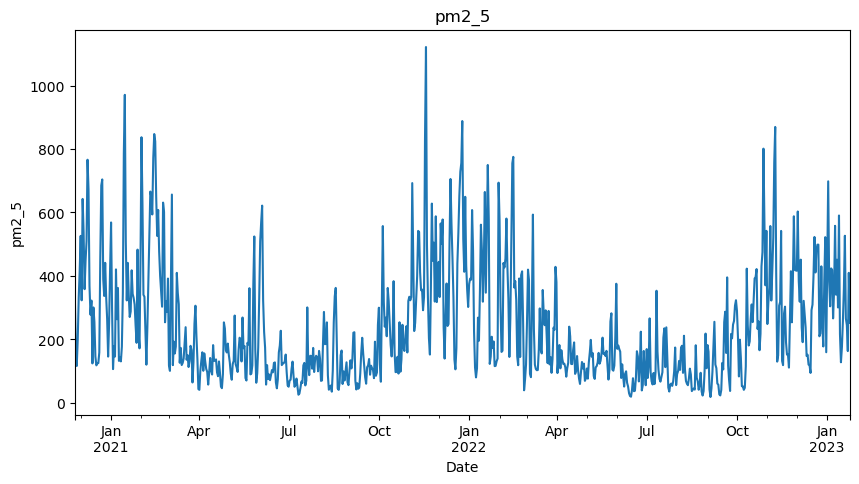

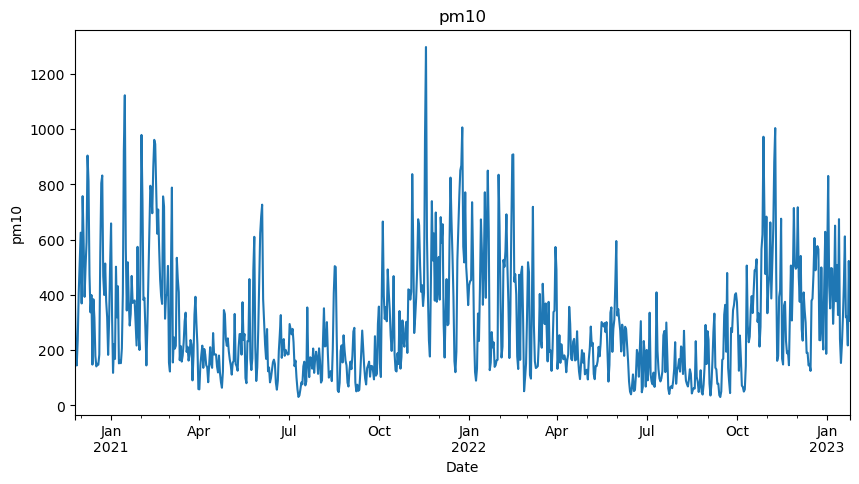

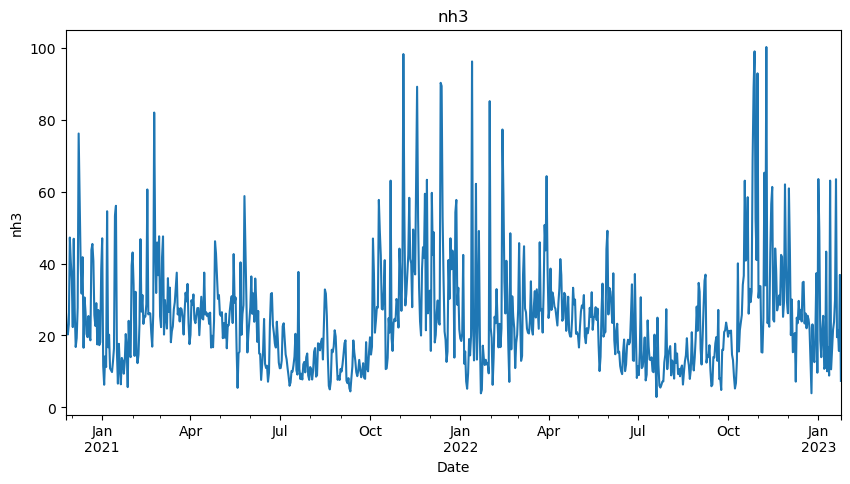

In [11]:
import matplotlib.pyplot as plt

# Plot each variable separately
for column in daily_data.columns:
    if column != 'date':
        daily_data[column].plot(figsize=(10, 5))
        plt.title(column)
        plt.xlabel('Date')
        plt.ylabel(column)
        plt.show()

In [12]:
from sklearn.model_selection import TimeSeriesSplit

# Sort the data by date
daily_data_sorted = daily_data.sort_index()

# Define the train-test split
train_size = 0.9
split_index = int(train_size * len(daily_data_sorted))

# Split the data
train_data = daily_data_sorted.iloc[:split_index]
test_data = daily_data_sorted.iloc[split_index:]

In [13]:
print(train_data)

                     co         no         no2          o3         so2  \
date                                                                     
2020-11-25  2971.566087  14.880000   93.549130   26.791304   82.430870   
2020-11-26  2314.806667  24.443750   65.418750   20.753333   65.158333   
2020-11-27  1592.159583   4.934167   56.221667   43.925000   41.485000   
2020-11-28  2461.115833  11.879583   70.046667   50.372500   41.515417   
2020-11-29  4516.680417  65.719583   93.949583   34.696250   77.785417   
...                 ...        ...         ...         ...         ...   
2022-11-01  3750.642083  55.218750   77.498750   34.722083   54.071250   
2022-11-02  3871.362500  39.755000   88.466250   39.817917   60.498750   
2022-11-03  4886.302500  69.931250   82.855417   45.610833   68.160417   
2022-11-04  5640.000000  33.780833  131.989167  126.624167  104.187083   
2022-11-05  2479.568333   5.333333   66.888750   71.862083   41.754167   

                 pm2_5        pm10   

In [14]:
print(test_data)

                      co          no         no2         o3         so2  \
date                                                                      
2022-11-06   4120.032083   51.630000   73.443750  48.687500   52.580833   
2022-11-07   6051.540417   85.121250  157.939167  24.481250  138.541250   
2022-11-08   7650.375000   98.785000  135.405833  12.805000  118.493750   
2022-11-09  10482.548750  204.927917  213.660000  29.320417  255.961667   
2022-11-10   4701.375417   62.679583   95.177083  31.742083   75.380833   
...                  ...         ...         ...        ...         ...   
2023-01-20   2770.979583   25.315000   64.618750  27.460833   55.958333   
2023-01-21   2263.070000   12.883750   66.103750  25.228333   57.868750   
2023-01-22   1404.961250    6.172917   33.536667  27.261667   22.238333   
2023-01-23   4799.564583   81.782500   77.383750  26.542083   66.191667   
2023-01-24   1938.926667    9.371111   46.724444  32.718889   45.672222   

                 pm2_5  

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor

In [16]:
# Standardize the data for ANN
scaler_ann = StandardScaler()
X_train_scaled_ann = scaler_ann.fit_transform(train_data.drop(columns=['pm2_5']))
X_test_scaled_ann = scaler_ann.transform(test_data.drop(columns=['pm2_5']))

In [17]:
# Standardize the data for XGBoost
scaler_xgb = StandardScaler()
X_train_scaled_xgb = scaler_xgb.fit_transform(train_data.drop(columns=['pm2_5']))
X_test_scaled_xgb = scaler_xgb.transform(test_data.drop(columns=['pm2_5']))

In [18]:
# Extract target variable
y_train = train_data['pm2_5']
y_test = test_data['pm2_5']

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [20]:
# Train ANN model
ann_params = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'max_iter': [500, 1000],
    'alpha': [0.0001, 0.001, 0.01],
}

ann_model = MLPRegressor(random_state=42)
ann_grid = GridSearchCV(ann_model, ann_params, cv=5, scoring='neg_mean_squared_error')
ann_grid.fit(X_train_scaled_ann, y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_m

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_mult

GridSearchCV(cv=5, estimator=MLPRegressor(random_state=42),
             param_grid={'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (100, 50)],
                         'max_iter': [500, 1000]},
             scoring='neg_mean_squared_error')

In [21]:
# Best parameters for ANN
print("Best parameters for ANN:", ann_grid.best_params_)


Best parameters for ANN: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'max_iter': 1000}


In [22]:
# Train Random Forest model with GridSearchCV
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
}

rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='neg_mean_squared_error')
rf_grid.fit(X_train_scaled_xgb, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [23]:
# Best parameters for Random Forest
print("Best parameters for Random Forest:", rf_grid.best_params_)


Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}


In [24]:
# XGBoost
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

xgb_model = XGBRegressor(random_state=42)
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='neg_mean_squared_error')
xgb_grid.fit(X_train_scaled_xgb, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [25]:
# Best parameters
print("Best parameters for XGBoost:", xgb_grid.best_params_)


Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [26]:
# Predictions
ann_pred = ann_grid.predict(X_test_scaled_ann)
rf_pred = rf_grid.predict(X_test_scaled_xgb)
xgb_pred = xgb_grid.predict(X_test_scaled_xgb)

In [27]:
# Stacking model using Linear Regression as meta-regressor
meta_regressor = LinearRegression()
stacked_model = StackingRegressor(
    estimators=[
        ('ann', ann_grid.best_estimator_),
        ('xgb', xgb_grid.best_estimator_),
        ('rf', rf_grid.best_estimator_)
    ],
    final_estimator=meta_regressor
)

stacked_model.fit(X_train_scaled_ann, y_train)  # Use scaled features for ANN


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_m

StackingRegressor(estimators=[('ann',
                               MLPRegressor(alpha=0.001,
                                            hidden_layer_sizes=(100, 50),
                                            max_iter=1000, random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=No...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=7,
                                                     n_estimators=200,
                                                     random_state=42))],
                  final_estimator=LinearRegression())

In [28]:
# Predictions
stacked_pred = stacked_model.predict(X_test_scaled_ann)

In [29]:
# ANN
ann_rmse = np.sqrt(mean_squared_error(y_test, ann_pred))
ann_mae = mean_absolute_error(y_test, ann_pred)
ann_r2 = r2_score(y_test, ann_pred)

print("ANN RMSE:", ann_rmse)
print("ANN MAE:", ann_mae)
print("ANN R-squared:", ann_r2)

# XGBoost
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)
print("XGBoost R-squared:", xgb_r2)

# Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest R-squared:", rf_r2)

# Stacked Model
stacked_rmse = np.sqrt(mean_squared_error(y_test, stacked_pred))
stacked_mae = mean_absolute_error(y_test, stacked_pred)
stacked_r2 = r2_score(y_test, stacked_pred)

print("Stacked Model RMSE:", stacked_rmse)
print("Stacked Model MAE:", stacked_mae)
print("Stacked Model R-squared:", stacked_r2)

ANN RMSE: 17.06438701224695
ANN MAE: 13.125517687929156
ANN R-squared: 0.9886559333239483
XGBoost RMSE: 26.60331975516207
XGBoost MAE: 16.381942459824877
XGBoost R-squared: 0.97242858501259
Random Forest RMSE: 26.404106302972686
Random Forest MAE: 18.913602797517495
Random Forest R-squared: 0.9728399646242252
Stacked Model RMSE: 16.763419769314545
Stacked Model MAE: 13.088041073643575
Stacked Model R-squared: 0.9890525586638889


In [30]:
# Print actual and predicted values
results = pd.DataFrame({'Actual': y_test, 
                        'ANN Predicted': ann_pred, 
                        'XGBoost Predicted': xgb_pred,
                        'RF Predicted': rf_pred,
                        'Stacked Predicted': stacked_pred})
print(results)

                Actual  ANN Predicted  XGBoost Predicted  RF Predicted  \
date                                                                     
2022-11-06  414.982917     428.696930         431.732025    433.205481   
2022-11-07  519.599167     527.045597         537.071594    542.539174   
2022-11-08  757.260833     779.726750         746.546753    764.474152   
2022-11-09  869.540833     853.209845        1030.965454    922.525156   
2022-11-10  407.581250     407.182592         401.693451    391.399886   
...                ...            ...                ...           ...   
2023-01-20  265.761667     267.420683         254.578354    251.530741   
2023-01-21  245.029583     258.102448         239.666061    224.507441   
2023-01-22  162.943333     104.650738         135.951248    130.632888   
2023-01-23  409.547083     419.499842         434.843323    444.136282   
2023-01-24  251.776667     280.754134         210.039902    218.376054   

            Stacked Predicted  
date 

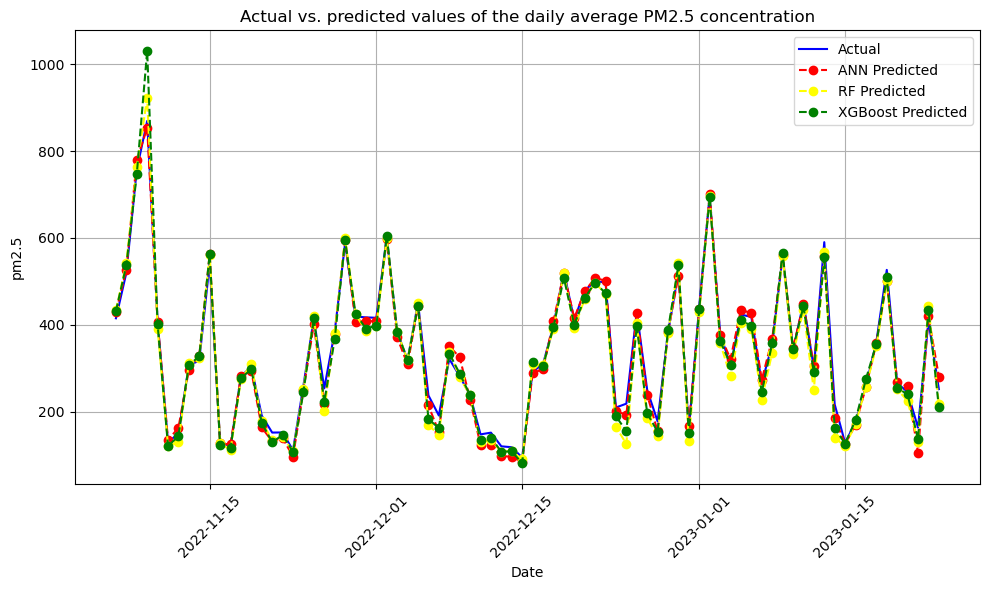

In [31]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(results.index, results['Actual'], label='Actual', color='blue')
plt.plot(results.index, results['ANN Predicted'], label='ANN Predicted', linestyle='--', marker='o', color='red')
plt.plot(results.index, results['RF Predicted'], label='RF Predicted', linestyle='--', marker='o', color='yellow')
plt.plot(results.index, results['XGBoost Predicted'], label='XGBoost Predicted', linestyle='--', marker='o', color='green')

plt.title('Actual vs. predicted values of the daily average PM2.5 concentration')
plt.xlabel('Date')
plt.ylabel('pm2.5')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
from sklearn.svm import SVR
# Stacking model using SVR as meta-regressor
meta_regressor = SVR()
stacked_model = StackingRegressor(
    estimators=[
        ('ann', ann_grid.best_estimator_),
        ('xgb', xgb_grid.best_estimator_),
        ('rf', rf_grid.best_estimator_)
    ],
    final_estimator=meta_regressor
)

stacked_model.fit(X_train_scaled_ann, y_train)  # Use scaled features for ANN


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_m

StackingRegressor(estimators=[('ann',
                               MLPRegressor(alpha=0.001,
                                            hidden_layer_sizes=(100, 50),
                                            max_iter=1000, random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=No...
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=7,
                                                     n_estimators=200,
                                                     random_state=42))],
                  final_estimator=SVR())

In [32]:

# Predictions
stacked_pred2 = stacked_model.predict(X_test_scaled_ann)

In [33]:
# Stacked Model
stacked_rmse = np.sqrt(mean_squared_error(y_test, stacked_pred2))
stacked_mae = mean_absolute_error(y_test, stacked_pred2)
stacked_r2 = r2_score(y_test, stacked_pred2)

print("Stacked Model RMSE:", stacked_rmse)
print("Stacked Model MAE:", stacked_mae)
print("Stacked Model R-squared:", stacked_r2)

Stacked Model RMSE: 127.45766396284618
Stacked Model MAE: 69.55806281885305
Stacked Model R-squared: 0.36712302578178724


In [32]:
from sklearn.neural_network import MLPRegressor

# Stacking model using ANN as meta-regressor
meta_regressor = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)
stacked_model = StackingRegressor(
    estimators=[
        ('ann', ann_grid.best_estimator_),
        ('xgb', xgb_grid.best_estimator_),
        ('rf', rf_grid.best_estimator_)

    ],
    final_estimator=meta_regressor
)

stacked_model.fit(X_train_scaled_ann, y_train)  # Use scaled features for ANN


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_m

StackingRegressor(estimators=[('ann',
                               MLPRegressor(alpha=0.001,
                                            hidden_layer_sizes=(100, 50),
                                            max_iter=1000, random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=No...
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=7,
                                                     n_estimators=200,
                                                     random_state=42))],
                  final_estimator=MLPRegressor(hidden_layer_sizes=(50, 50),
                                               max_iter=1000, random_state=42))

In [33]:
# Make predictions on the test set
final_predictions = stacked_model.predict(X_test_scaled_ann)  # Use the same scaled features for ANN

# Evaluate the model
mse = mean_squared_error(y_test, final_predictions)
mae = mean_absolute_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

print(f'Stacked Model RMSE: {np.sqrt(mse)}')
print(f'Stacked Model MAE: {mae}')
print(f'Stacked Model R-squared: {r2}')


Stacked Model RMSE: 16.688529951080387
Stacked Model MAE: 12.974995553979772
Stacked Model R-squared: 0.989150154569433


In [34]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions from your models
ann_pred = ann_grid.predict(X_test_scaled_ann)
rf_pred = rf_grid.predict(X_test_scaled_xgb)
xgb_pred = xgb_grid.predict(X_test_scaled_xgb)

# Weights based on inverse RMSE (normalized)
weights = {
    'ann': 0.437,
    'xgb': 0.281,
    'rf': 0.282
}

# Weighted averaging of predictions
y_pred_ensemble = (weights['ann'] * ann_pred +
                   weights['xgb'] * xgb_pred +
                   weights['rf'] * rf_pred)

# Calculate performance metrics for the ensemble model
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

print(f'Ensemble RMSE: {rmse_ensemble}')
print(f'Ensemble MAE: {mae_ensemble}')
print(f'Ensemble R-squared: {r2_ensemble}')


Ensemble RMSE: 18.42219523340736
Ensemble MAE: 13.2298203110125
Ensemble R-squared: 0.9867788221540845


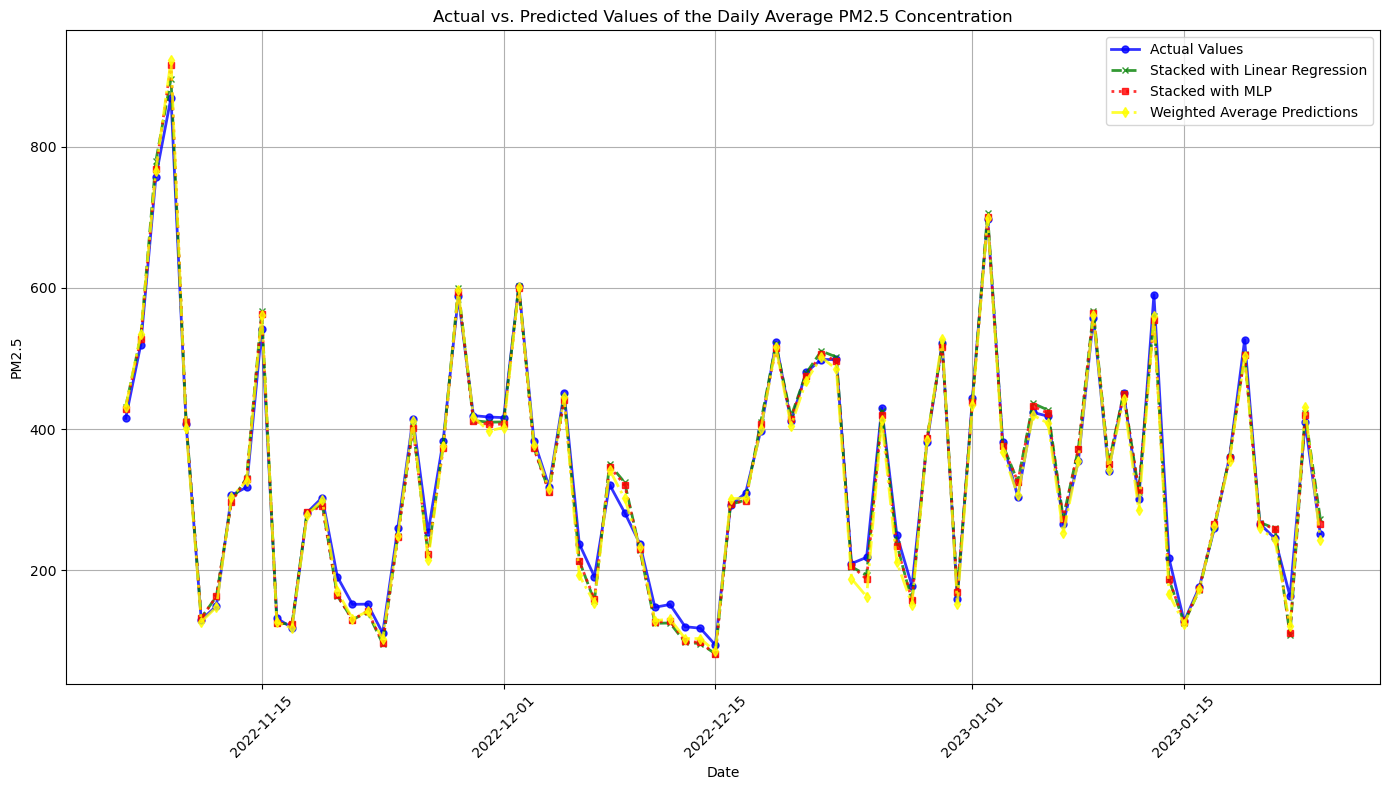

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test is already a pandas Series with a datetime index
# Convert numpy arrays to pandas Series with the same index as y_test
stacked_pred = pd.Series(data=stacked_pred, index=y_test.index)
final_predictions = pd.Series(data=final_predictions, index=y_test.index)
y_pred_ensemble = pd.Series(data=y_pred_ensemble, index=y_test.index)

plt.figure(figsize=(14, 8))

# Plot actual values
plt.plot(y_test.index, y_test, label='Actual Values', color='blue', marker='o', linestyle='-', markersize=5, alpha=0.8, linewidth=2)

# Plot stacked_pred values
plt.plot(stacked_pred.index, stacked_pred, label='Stacked with Linear Regression', color='green', marker='x', linestyle='--', markersize=5, alpha=0.8, linewidth=2)

# Plot final_predictions values
plt.plot(final_predictions.index, final_predictions, label='Stacked with MLP', color='red', marker='s', linestyle=':', markersize=5, alpha=0.8, linewidth=2)

# Plot y_pred_ensemble values
plt.plot(y_pred_ensemble.index, y_pred_ensemble, label='Weighted Average Predictions', color='yellow', marker='d', linestyle='-.', markersize=5, alpha=0.8, linewidth=2)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.title('Actual vs. Predicted Values of the Daily Average PM2.5 Concentration')
plt.legend()
plt.grid(True)

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


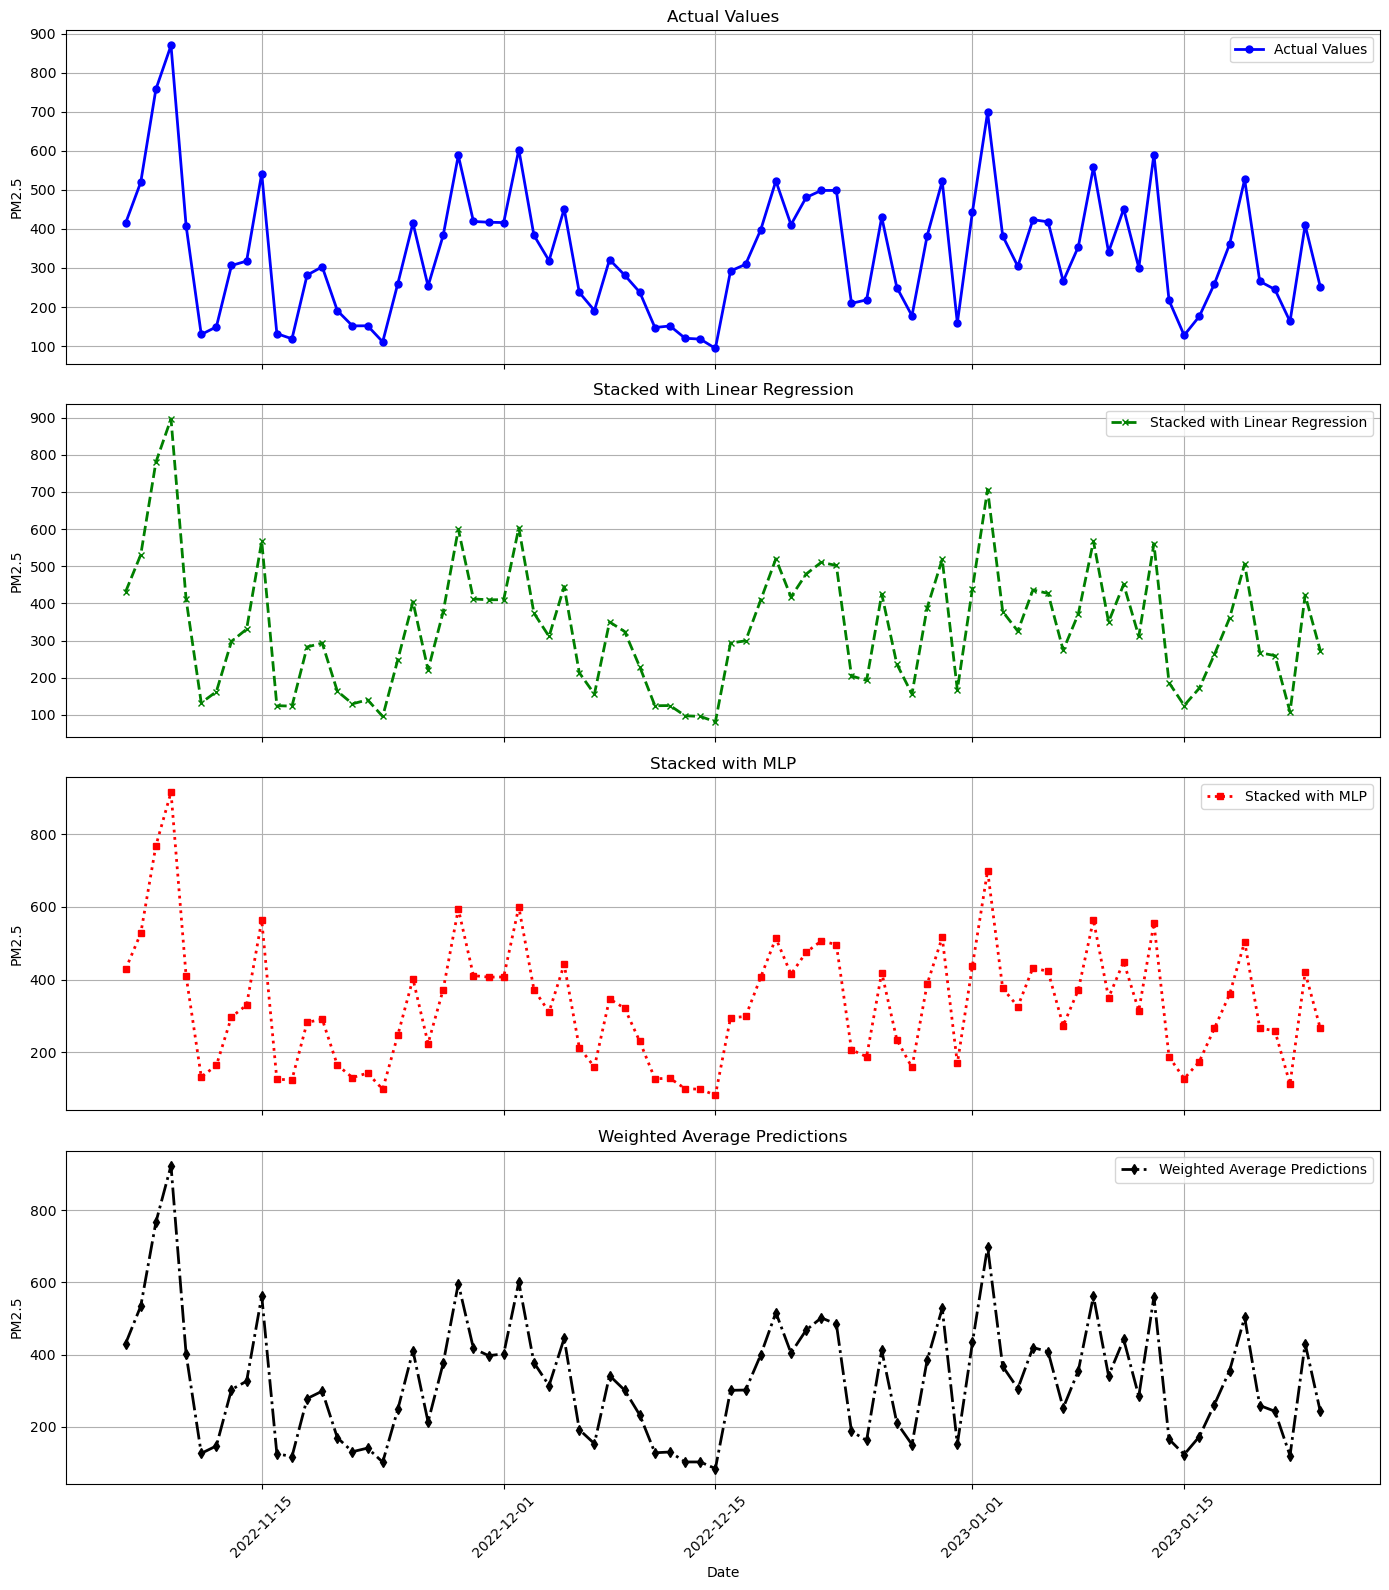

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test is already a pandas Series with a datetime index
# Convert numpy arrays to pandas Series with the same index as y_test
stacked_pred = pd.Series(data=stacked_pred, index=y_test.index)
final_predictions = pd.Series(data=final_predictions, index=y_test.index)
y_pred_ensemble = pd.Series(data=y_pred_ensemble, index=y_test.index)

# Create a figure with subplots
fig, axs = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Plot actual values
axs[0].plot(y_test.index, y_test, label='Actual Values', color='blue', marker='o', linestyle='-', markersize=5, linewidth=2)
axs[0].set_title('Actual Values')
axs[0].set_ylabel('PM2.5')
axs[0].legend()
axs[0].grid(True)

# Plot stacked_pred values
axs[1].plot(stacked_pred.index, stacked_pred, label='Stacked with Linear Regression', color='green', marker='x', linestyle='--', markersize=5, linewidth=2)
axs[1].set_title('Stacked with Linear Regression')
axs[1].set_ylabel('PM2.5')
axs[1].legend()
axs[1].grid(True)

# Plot final_predictions values
axs[2].plot(final_predictions.index, final_predictions, label='Stacked with MLP', color='red', marker='s', linestyle=':', markersize=5, linewidth=2)
axs[2].set_title('Stacked with MLP')
axs[2].set_ylabel('PM2.5')
axs[2].legend()
axs[2].grid(True)

# Plot y_pred_ensemble values
axs[3].plot(y_pred_ensemble.index, y_pred_ensemble, label='Weighted Average Predictions', color='black', marker='d', linestyle='-.', markersize=5, linewidth=2)
axs[3].set_title('Weighted Average Predictions')
axs[3].set_ylabel('PM2.5')
axs[3].set_xlabel('Date')
axs[3].legend()
axs[3].grid(True)

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


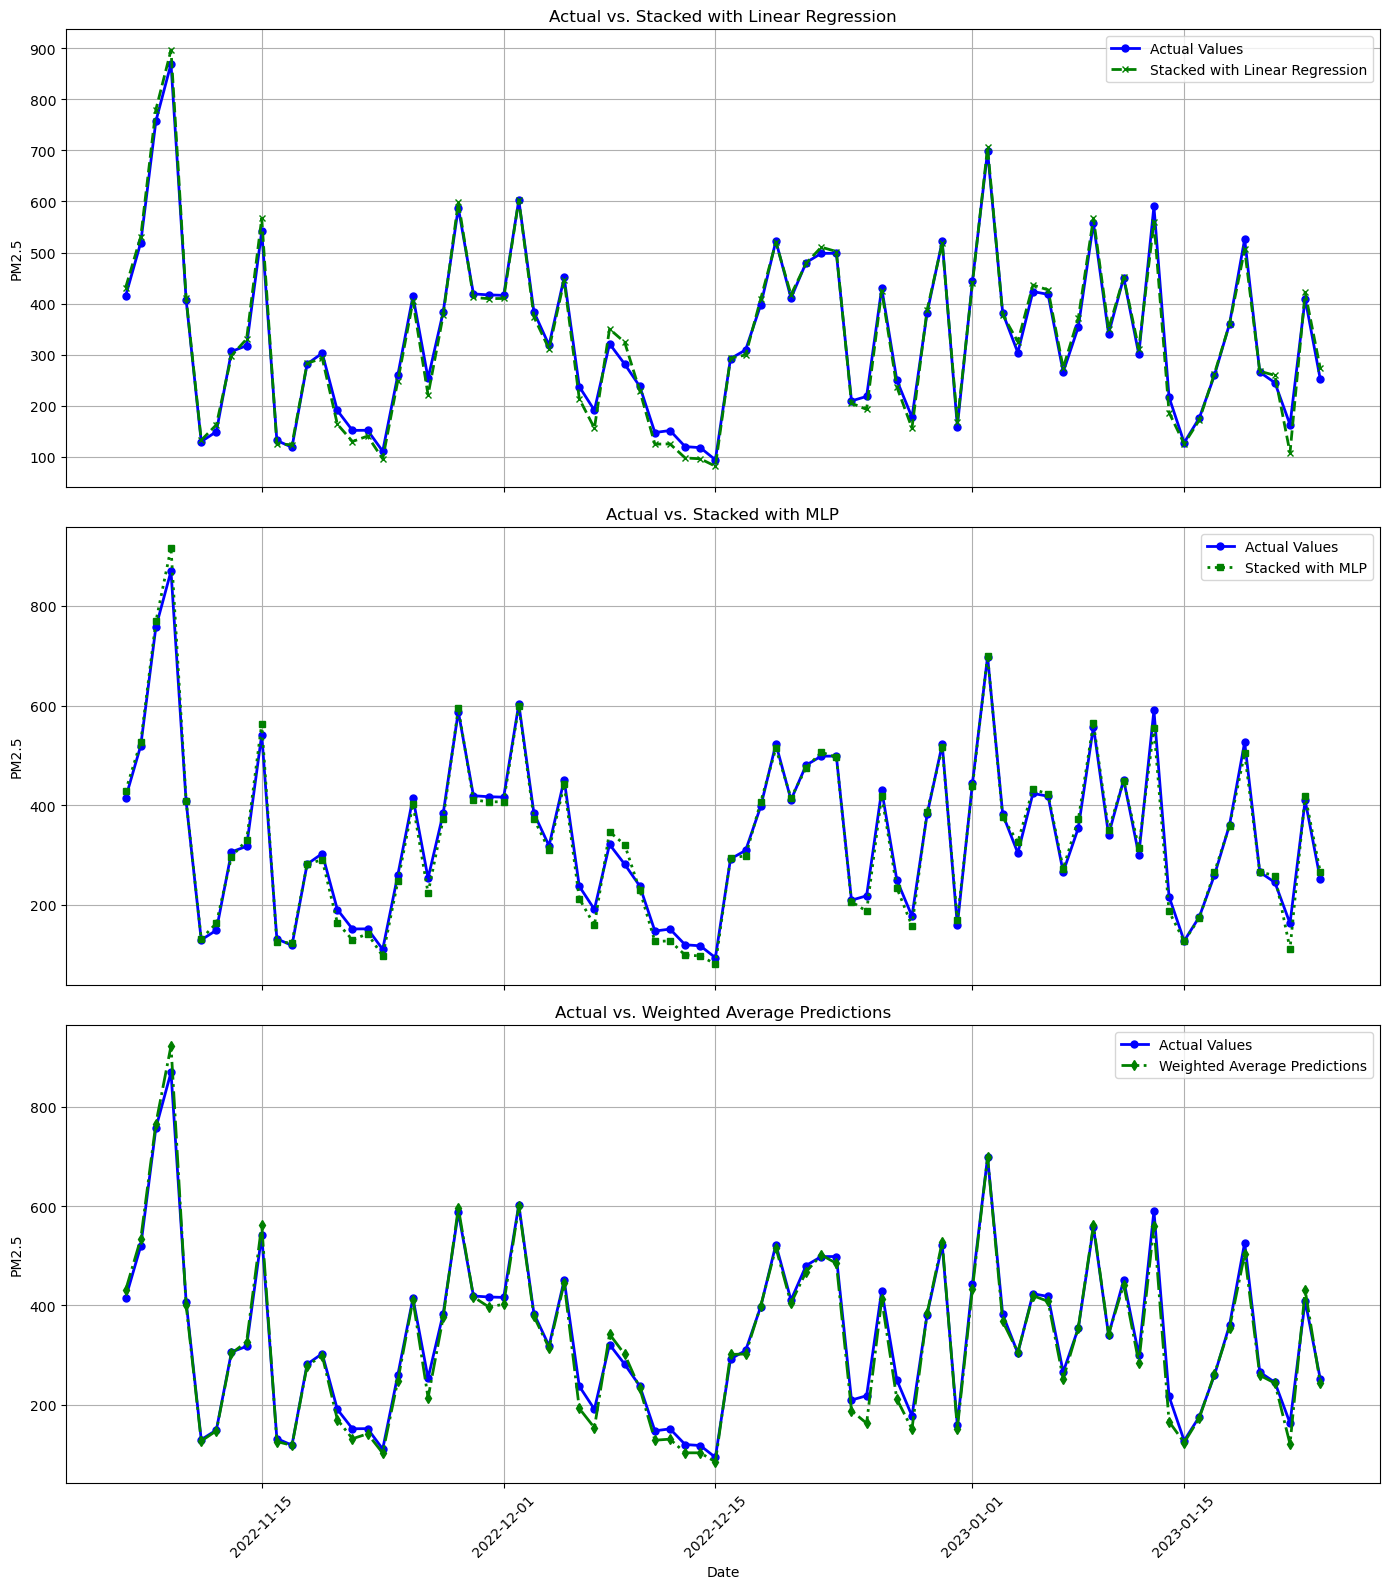

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test is already a pandas Series with a datetime index
# Convert numpy arrays to pandas Series with the same index as y_test
stacked_pred = pd.Series(data=stacked_pred, index=y_test.index)
final_predictions = pd.Series(data=final_predictions, index=y_test.index)
y_pred_ensemble = pd.Series(data=y_pred_ensemble, index=y_test.index)

# Create a figure with subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# Plot actual values with each method's predictions
axs[0].plot(y_test.index, y_test, label='Actual Values', color='blue', marker='o', linestyle='-', markersize=5, linewidth=2)
axs[0].plot(stacked_pred.index, stacked_pred, label='Stacked with Linear Regression', color='green', marker='x', linestyle='--', markersize=5, linewidth=2)
axs[0].set_title('Actual vs. Stacked with Linear Regression')
axs[0].set_ylabel('PM2.5')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(y_test.index, y_test, label='Actual Values', color='blue', marker='o', linestyle='-', markersize=5, linewidth=2)
axs[1].plot(final_predictions.index, final_predictions, label='Stacked with MLP', color='green', marker='s', linestyle=':', markersize=5, linewidth=2)
axs[1].set_title('Actual vs. Stacked with MLP')
axs[1].set_ylabel('PM2.5')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(y_test.index, y_test, label='Actual Values', color='blue', marker='o', linestyle='-', markersize=5, linewidth=2)
axs[2].plot(y_pred_ensemble.index, y_pred_ensemble, label='Weighted Average Predictions', color='green', marker='d', linestyle='-.', markersize=5, linewidth=2)
axs[2].set_title('Actual vs. Weighted Average Predictions')
axs[2].set_ylabel('PM2.5')
axs[2].set_xlabel('Date')
axs[2].legend()
axs[2].grid(True)

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


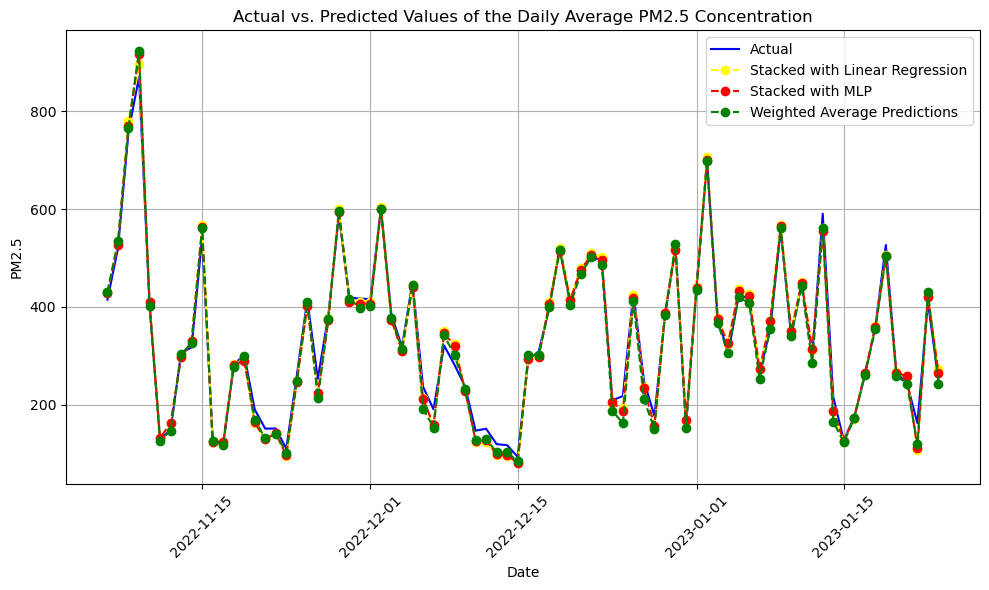

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test is already a pandas Series with a datetime index
# Convert numpy arrays to pandas Series with the same index as y_test
stacked_pred = pd.Series(data=stacked_pred, index=y_test.index)
final_predictions = pd.Series(data=final_predictions, index=y_test.index)
y_pred_ensemble = pd.Series(data=y_pred_ensemble, index=y_test.index)

# Combine all data into a DataFrame for easier plotting
results = pd.DataFrame({
    'Actual': y_test,
    'Stacked with Linear Regression': stacked_pred,
    'Stacked with MLP': final_predictions,
    'Weighted Average Predictions': y_pred_ensemble
})

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))

plt.plot(results.index, results['Actual'], label='Actual', color='blue')
plt.plot(results.index, results['Stacked with Linear Regression'], label='Stacked with Linear Regression', linestyle='--', marker='o', color='yellow')
plt.plot(results.index, results['Stacked with MLP'], label='Stacked with MLP', linestyle='--', marker='o', color='red')
plt.plot(results.index, results['Weighted Average Predictions'], label='Weighted Average Predictions', linestyle='--', marker='o', color='green')

plt.title('Actual vs. Predicted Values of the Daily Average PM2.5 Concentration')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
